In [70]:
# Libraries
import time
import os
import random
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader

# Custom
from datasets.smdg import SMDGDataset

# Global variables
IMAGES_PATH='./data/'
DATASET_PATH='./data/metadata.csv'
RESULTS_PATH='./results/'
MODELS_PATH = './results/models_trained'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
TARGET = 'types'

Statistics

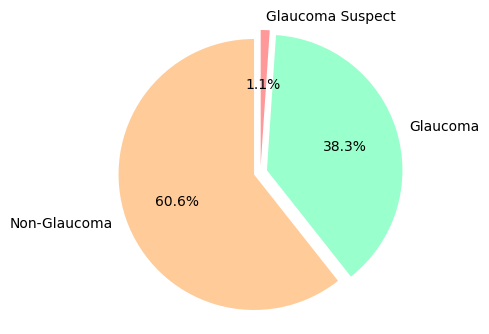

In [71]:
df = pd.read_csv(DATASET_PATH)

# Mapeamento das classes
label_map = {
    -1: 'Glaucoma Suspect',
     0: 'Non-Glaucoma',
     1: 'Glaucoma'
}

# Contagem das classes
counts = df[TARGET].value_counts()
labels = [label_map[i] for i in counts.index]

# Cria um explode para destacar cada fatia (ajuste os valores como quiser)
explode = [0.05] * len(counts)  # todas as fatias levemente separadas

# Cores personalizadas (opcional)
colors = ['#ffcc99', '#99ffcc', '#ff9999']

# Plot
plt.figure(figsize=(4, 4))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=colors, explode=explode, shadow=False)
plt.axis('equal')  # garante formato circular
plt.show()


In [72]:
vgg16fe = pd.read_csv(os.path.join(RESULTS_PATH+'./vgg16-fe.csv'))
vgg16ft3 = pd.read_csv(os.path.join(RESULTS_PATH+'./vgg16-ft3.csv'))
vgg16ft6 = pd.read_csv(os.path.join(RESULTS_PATH+'./vgg16-ft6.csv'))
resnet50fe = pd.read_csv(os.path.join(RESULTS_PATH+'./resnet50-fe.csv'))
resnet50ft1 = pd.read_csv(os.path.join(RESULTS_PATH+'./resnet50-ft1.csv'))

In [22]:
def loss_acc_plot(model_stats):
  # Criação dos subplots lado a lado
  fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

  # Acurácia de Treino e Teste(esquerda)
  axes[0].plot(model_stats['epoch'], model_stats['train_acc'], label='Acuracia Treino', marker='o')
  axes[0].plot(model_stats['epoch'], model_stats['val_acc'], label='Acuracia Teste', marker='o')
  axes[0].set_title('Acurácia de treino e teste')
  axes[0].set_xlabel('Época')
  axes[0].set_ylabel('Acurácia')
  axes[0].legend()
  axes[0].grid(True)

  # Loss de Treino e Teste (direita)
  axes[1].plot(model_stats['epoch'], model_stats['train_loss'], label='Loss Treino', marker='o')
  axes[1].plot(model_stats['epoch'], model_stats['val_loss'], label='Loss Teste', marker='o')
  axes[1].set_title('Loss de treino e teste')
  axes[1].set_xlabel('Época')
  axes[1].set_ylabel('Acurácia')
  axes[1].legend()
  axes[1].grid(True)

  # Ajuste final
  plt.tight_layout()
  plt.show()


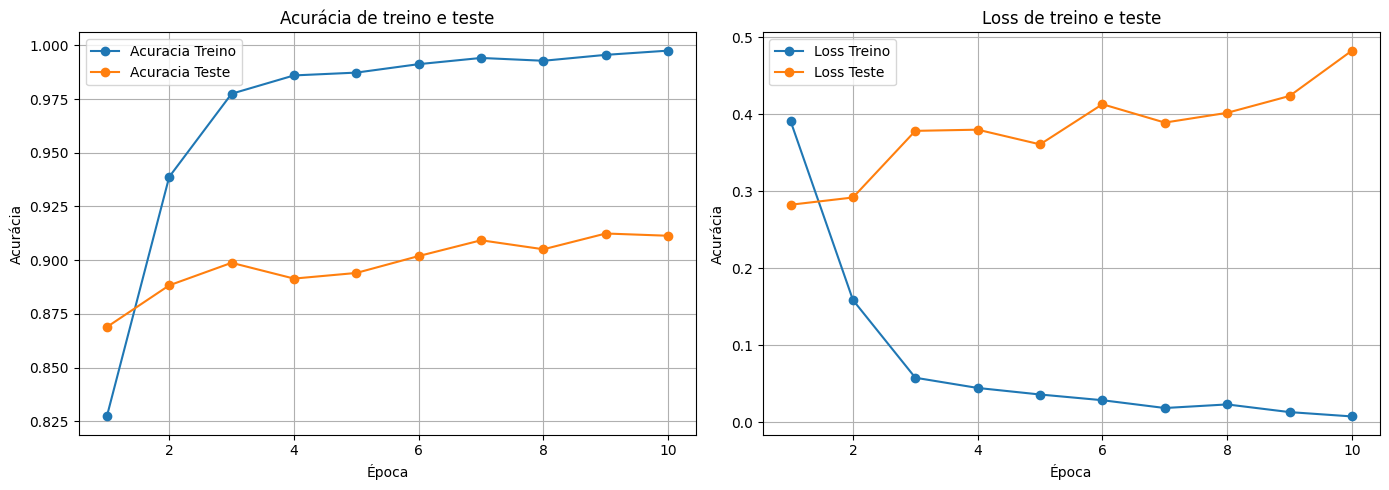

In [20]:
loss_acc_plot(resnet50ft1)

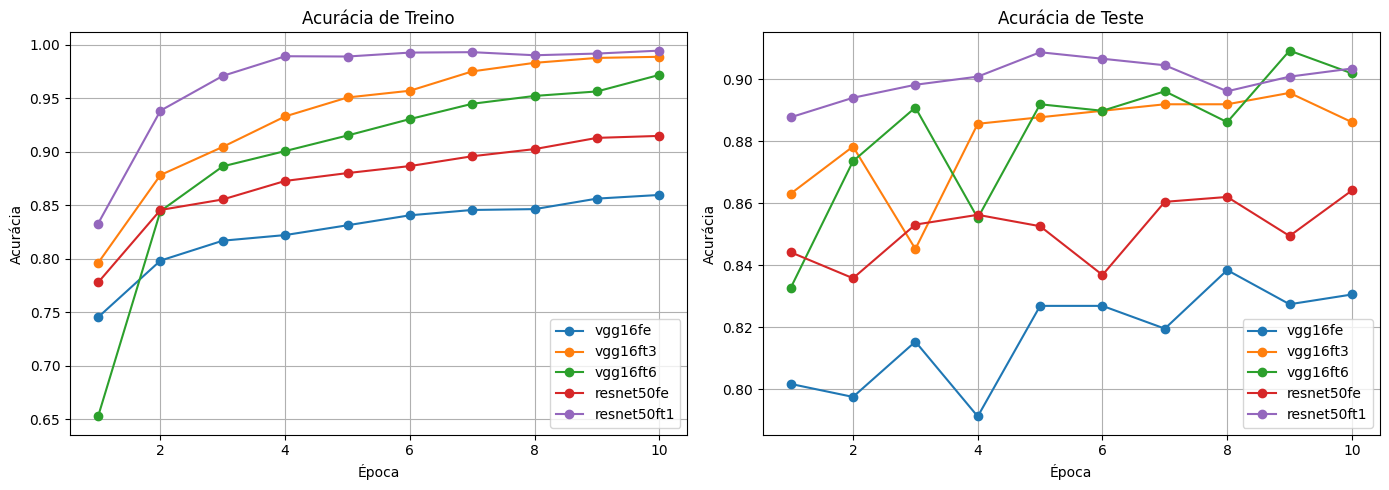

In [73]:
MODELS = {
    "vgg16fe": vgg16fe,
    "vgg16ft3": vgg16ft3,
    "vgg16ft6": vgg16ft6,
    "resnet50fe": resnet50fe,
    "resnet50ft1": resnet50ft1,
}

# Criação dos subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Acurácia e loss de Treino (esquerda)
for key, value in MODELS.items():
  axes[0].plot(value['epoch'], value['train_acc'], label=key, marker='o')
axes[0].set_title('Acurácia de Treino')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True)

# Acurácia de Validação/Teste (direita)
for key, value in MODELS.items():
  axes[1].plot(value['epoch'], value['val_acc'], label=key, marker='o')
axes[1].set_title('Acurácia de Teste')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(True)

# Ajuste final
plt.tight_layout()
plt.show()

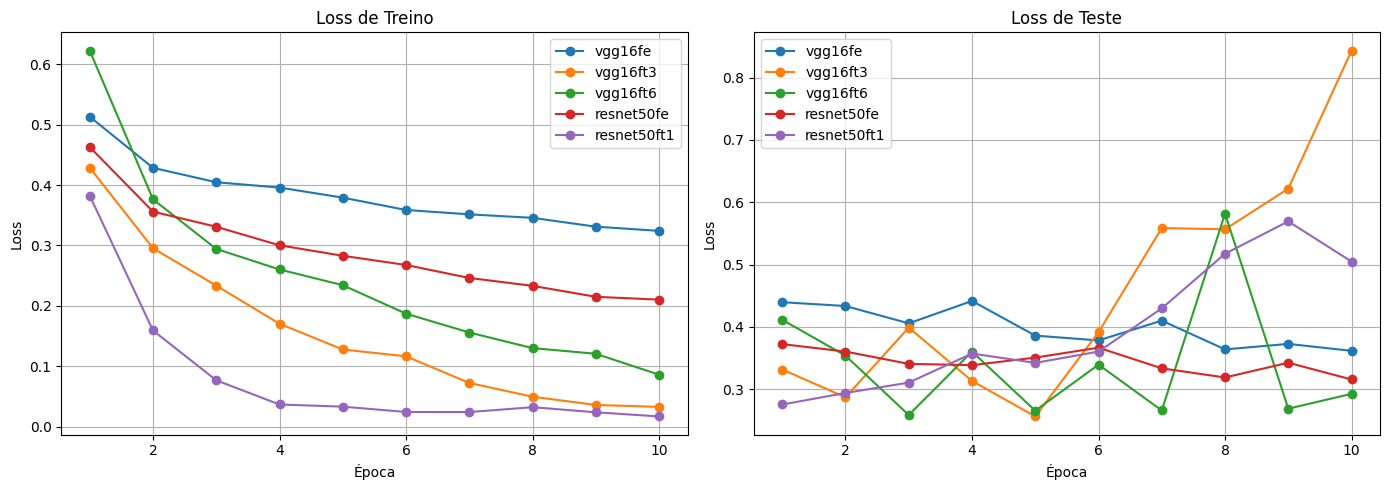

In [125]:
MODELS = {
    "vgg16fe": vgg16fe,
    "vgg16ft3": vgg16ft3,
    "vgg16ft6": vgg16ft6,
    "resnet50fe": resnet50fe,
    "resnet50ft1": resnet50ft1,
}

# Criação dos subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Loss de Treino (esquerda)
for key, value in MODELS.items():
  axes[0].plot(value['epoch'], value['train_loss'], label=key, marker='o')
axes[0].set_title('Loss de Treino')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Loss de Validação/Teste (direita)
for key, value in MODELS.items():
  axes[1].plot(value['epoch'], value['val_loss'], label=key, marker='o')
axes[1].set_title('Loss de Teste')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Ajuste final
plt.tight_layout()
plt.show()

# GradCAM

In [75]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.register_hooks()

    def set_target_layer(self, target_layer):
        self.target_layer = target_layer

        # Hook: salva ativações e gradientes
    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def register_hooks(self):
        # Registra os hooks
        self.fwd = self.target_layer.register_forward_hook(self.forward_hook)
        self.bwd = self.target_layer.register_full_backward_hook(self.backward_hook)

    def generate(self, input_tensor, class_idx=None):
        output = self.model(input_tensor)

        # Se for binário (1 saída), assume a classe positiva
        if class_idx is None:
            class_idx = 0

        # Zera gradientes antigos
        self.model.zero_grad()

        # Backward pass para o score da classe alvo
        target = output[:, class_idx]
        target.backward()

        # Obtém média dos gradientes no espaço HxW (global average pooling)
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])

        # Multiplica os gradientes pelas ativações
        activations = self.activations[0]
        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]

        # Soma os canais (dim=0) e aplica ReLU
        heatmap = torch.sum(activations, dim=0)
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)  # Normaliza entre 0 e 1

        return heatmap

    def remove_hooks(self):
        self.fwd.remove()
        self.bwd.remove()



In [ ]:
# Loads a model and use it in a test dataset
# The predicted values are appended to a new column
MODEL_NAME = 'resnet50-ft1.pt'

df = pd.read_csv(DATASET_PATH)
df = df[['types', 'fundus']]
    
min_class = len(df[df[TARGET]==1])
df = pd.concat([
    df[df[TARGET] == 1],
    df[df[TARGET] == 0].iloc[:min_class]
])

_ , test_df = train_test_split(df,
                               test_size=0.2,
                               stratify=df[TARGET],
                               random_state=42)

transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),  
        transforms.Normalize([0.485, 0.456, 0.406],
                            [0.229, 0.224, 0.225])
    ])


test_dataset = SMDGDataset(test_df, IMAGES_PATH, transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = torch.load(os.path.join(MODELS_PATH, MODEL_NAME), weights_only=False)

model.eval()
predictions = []

with torch.no_grad():
    for images, _ in test_loader:  
        images = images.to(DEVICE)
        outputs = model(images)
        preds = (outputs >= 0.5).long().squeeze()
        predictions.extend(preds.cpu().numpy())

test_dataset.df['predicted'] = predictions


In [77]:
total = len(test_dataset.df)
correct = len(test_dataset.df[test_dataset.df['types'] == test_dataset.df['predicted']])
print(f'total: {total}, correct: {correct}, wrong: {total-correct}')

total: 1907, correct: 1723, wrong: 184


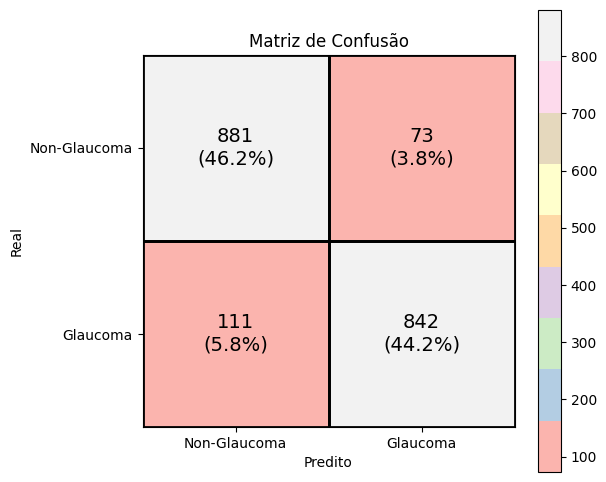

In [126]:
# Plot confusion matrix
from matplotlib.patches import Rectangle

# Real and predicted
y_true = test_dataset.df[TARGET]
y_pred = test_dataset.df['predicted']

cm = confusion_matrix(y_true, y_pred)
labels = ['Non-Glaucoma', 'Glaucoma']

cm_sum = np.sum(cm)
cm_percent = cm / cm_sum * 100

fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(cm, cmap='Pastel1')


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text = f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)"
        ax.text(j, i, text,
                ha="center", va="center", color="black", fontsize=14)
        
        rect = Rectangle((j - 0.5, i - 0.5), 1, 1,
                         linewidth=2, edgecolor='black', facecolor='none')
        ax.add_patch(rect)


ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.colorbar(im)
plt.show()

/tmp/ipykernel_52550/3425912389.py:58: RuntimeWarning: invalid value encountered in cast
  heatmap_colored = cv2.applyColorMap((255 * heatmap_resized).astype(np.uint8), cv2.COLORMAP_JET)


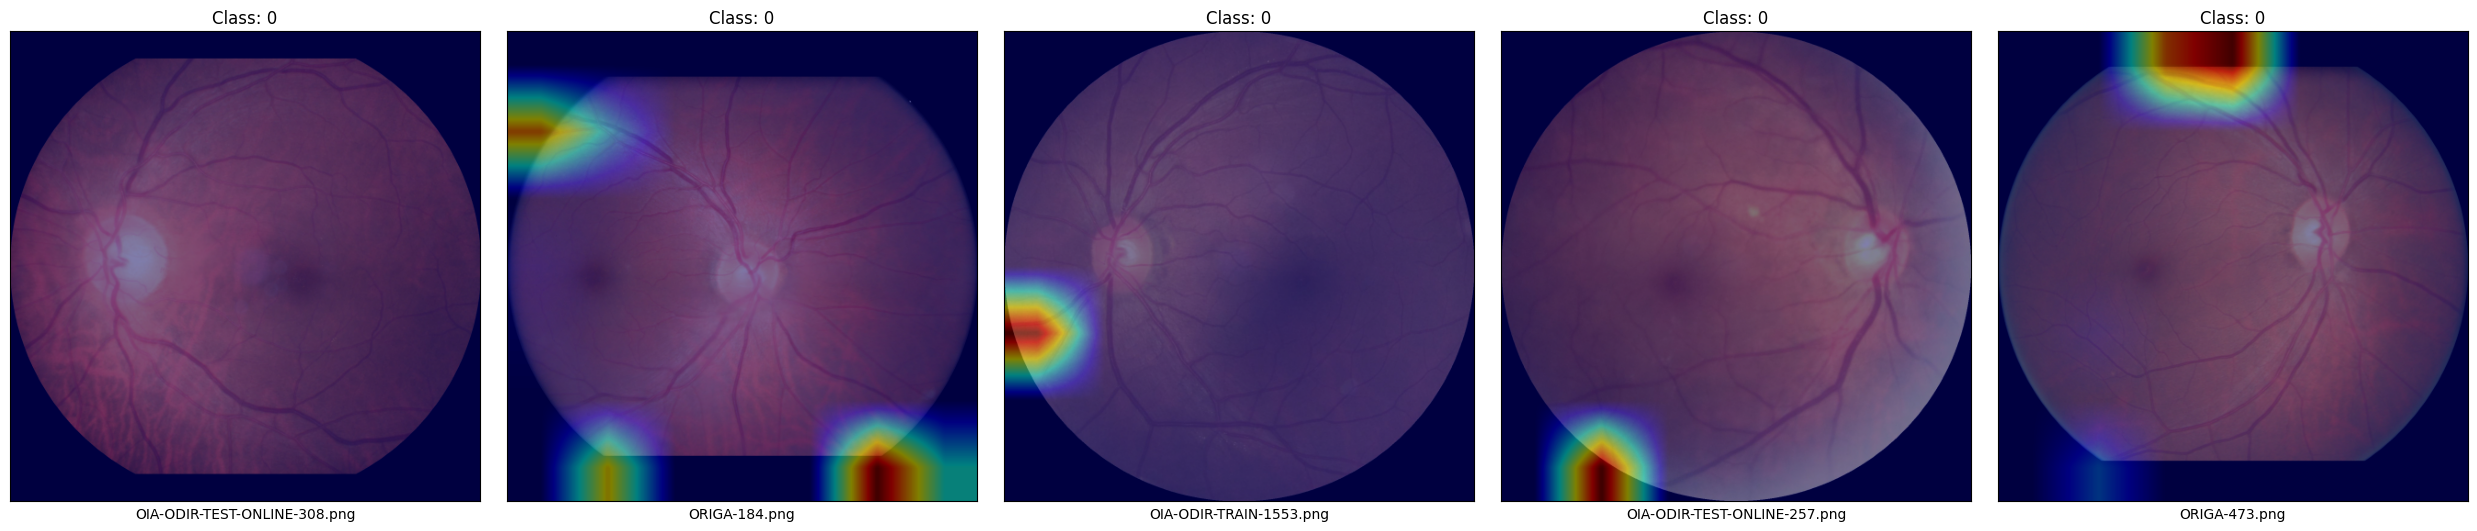

In [124]:
MODEL_NAME = 'resnet50-ft4.pt'
IMAGE = './full-fundus/BEH-172.png'


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

gradcam = GradCAM(model, model.layer4)

N=5

subset_df = test_dataset.df[
    (test_dataset.df['types'] == 0) &
    (test_dataset.df['predicted'] == 0)
]


available_indices = subset_df.index.tolist()

# Garante que não vai tentar pegar mais do que existe
N = min(N, len(available_indices))

# Seleciona N amostras aleatórias desse subset
sample_indices = random.sample(available_indices, N)

fig, axs = plt.subplots(1, N, figsize=(5*N, 5))

for i, idx in enumerate(sample_indices):
    
    img_path = os.path.join(IMAGES_PATH, test_dataset.df.loc[idx]['fundus'].strip('/'))
    image = Image.open(img_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0)
    image_tensor = image_tensor.to(DEVICE)
    
    # Gera heatmap
    heatmap = gradcam.generate(image_tensor)

    # heatmap tem shape (7, 7), transforma para (1, 1, 7, 7)
    heatmap = heatmap.unsqueeze(0).unsqueeze(0)

    # redimensiona para o tamanho original da imagem (H, W)
    heatmap = F.interpolate(heatmap, size=(image_tensor.size(2), image_tensor.size(3)), mode='bilinear', align_corners=False)
    
    # remove dimensões extras e normaliza
    heatmap = heatmap.squeeze()
    heatmap /= heatmap.max()
    heatmap = heatmap.cpu().numpy()
    
    # Para visualização
    image_np = np.array(image)
    heatmap_resized = cv2.resize(heatmap, (image_np.shape[1], image_np.shape[0]))
    
    if len(heatmap_resized.shape) == 2:
        heatmap_colored = cv2.applyColorMap((255 * heatmap_resized).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    overlay = cv2.addWeighted(image_np, 0.5, heatmap_colored, 0.5, 0)
    
    label = test_dataset.df.loc[idx][TARGET]

    axs[i].imshow(overlay)
    axs[i].set_title(f"Class: {label}")
    axs[i].set_xlabel(test_dataset.df.loc[idx]['fundus'].split('/')[-1]) 
    axs[i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)


plt.tight_layout()
plt.show()

gradcam.remove_hooks()